In [13]:
# General imports
import pandas as pd
import numpy as np
import itertools
import math
from tqdm import tqdm

# Import custom LIF SNN implementation
from LIF_SNN_network import SNNLayer

# Set random seed for reproducability
np.random.seed(42)

**Test data**

In [14]:
df_train = pd.read_csv("CSV_results/train_spike_trains.csv")
df_test = pd.read_csv("CSV_results/test_spike_trains.csv")

spike_cols = [c for c in df_train.columns if c.startswith("spike_")]

input_spikes      = [list(map(int, row)) for row in df_train[spike_cols].values]
correct_outputs   = df_train["label"].tolist()

test_dataset         = [list(map(int, row)) for row in df_test[spike_cols].values]
test_correct_outputs = df_test["label"].tolist()

**Parameters**

In [15]:
# Input/Output size — derived from the loaded CSV (see data cell above)
# Best preprocessing config: 8×3 grid + 4 dist bits + 5 aruco bins = 33
n_inputs  = len(spike_cols)   # 33
n_outputs = 3

# Aruco position within the spike vector: grid + dist → aruco at end
# 8*3=24 grid bins + 4 dist bits = 28 → aruco at indices 28..32
aruco_start = n_inputs - 5    # = 28
n_aruco     = 5

# Training params
n_epochs = 10
n_runs = 2

# Neuron hyperparameters
decay_range = [64]
threshold_range = [512]
reset_range = [0]

# Synapse parameters
lr_shift_range = [4]
initial_weight_range = [None]
t_pre_range = [3]
t_post_range = [2]
tau_e_shift_range = [2]
dw_pos_range = [32]
dw_neg_range = [2]
min_weight_range = [8]
max_weight_range = [255]

# Dopamine encoding: dopamine_code indexes into DOPAMINE_DECODE LUT
# With lr_shift=3: code=1 → ×1/8,  code=2 → ×2/8,  code=4 → ×4/8
reward_code_range = [0]   # ×4 / 2^lr_shift
punish_code_range = [0]   # ×1 / 2^lr_shift

mode_range = ['rstdp']

In [16]:
# Calculate total combinations and set up all configurations
ranges = [
    decay_range, threshold_range, reset_range,
    lr_shift_range, initial_weight_range,
    t_pre_range, t_post_range, tau_e_shift_range,
    dw_pos_range, dw_neg_range,
    min_weight_range, max_weight_range,
    reward_code_range, punish_code_range,
    mode_range
]

# Printing the total number of configurations
total_configurations = math.prod(map(len, ranges))
print(f"Number of configurations: ", total_configurations)

Number of configurations:  1


**Logging network activity**

In [17]:
# Initialize history lists
tuning_results = []
mean_run_acc = []
epoch_acc = []
num_correct = 0

In [18]:
def parse_aruco_state(spike_row, aruco_start, n_aruco):
    aruco = spike_row[aruco_start : aruco_start + n_aruco]
    seen  = bool(any(aruco))
    if not seen:
        return False, 0
    b = int(np.argmax(aruco))
    c = n_aruco // 2
    return True, (0 if b == c else (-1 if b < c else +1))


def reward_signal(seen, pos, action_idx, reward_code, punish_code):
    """Returns (dopamine_code, dopamine_sign, dopamine_enable)."""
    if seen and (
        (pos == 0  and action_idx == 1) or
        (pos == -1 and action_idx == 0) or
        (pos == +1 and action_idx == 2)
    ):
        return reward_code, 1, 1   # correct alignment action: reward

    if not seen and action_idx in (0, 2):
        return 1, 1, 1             # searching: weak reward (code=1 → ×1)

    return punish_code, 0, 1      # everything else: punish

**Run hyperparameter tuning**

In [19]:
for config in tqdm(itertools.product(*ranges), total=total_configurations):
    (decay, threshold, reset,
     lr_shift, initial_weight,
     t_pre, t_post, tau_e_shift,
     dw_pos, dw_neg,
     min_weight, max_weight,
     reward_code, punish_code,
     mode) = config

    neuron_params = {"decay": decay, "threshold": threshold, "reset": reset}
    synapse_params = {"lr_shift": lr_shift, "w_init": initial_weight,
                      "t_pre": t_pre, "t_post": t_post, "tau_e_shift": tau_e_shift,
                      "dw_pos": dw_pos, "dw_neg": dw_neg,
                      "w_min": min_weight, "w_max": max_weight,
                      "mode": mode}

    all_run_accs = []
    all_runs_test_acc = []

    for r in range(n_runs):
        SNN = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs,
                       synapse_params=synapse_params, neuron_params=neuron_params)

        epoch_acc = []
        epoch_test_acc = []

        for n in range(n_epochs):
            SNN.reset_state()
            num_correct = 0

            # --- TRAINING ---
            for current_spikes, correct_output in zip(input_spikes, correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                seen, pos          = parse_aruco_state(current_spikes, aruco_start, n_aruco)
                code, sign, enable = reward_signal(seen, pos, winner_idx, reward_code, punish_code)
                if enable:
                    SNN.apply_reward(dopamine_code=code, dopamine_sign=sign, winner_idx=winner_idx)

                if winner_idx == correct_output:
                    num_correct += 1

            epoch_acc.append(num_correct / len(input_spikes))

            # --- TESTING ---
            SNN.reset_state()
            num_test_correct = 0

            for current_spikes, correct_output in zip(test_dataset, test_correct_outputs):
                output_spikes = SNN.forward(input_spikes=current_spikes)
                winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

                if winner_idx == correct_output:
                    num_test_correct += 1

            epoch_test_acc.append(num_test_correct / len(test_dataset))

        all_run_accs.append(np.mean(epoch_acc))
        all_runs_test_acc.append(np.mean(epoch_test_acc))

    tuning_results.append(
        neuron_params | synapse_params | {
            "reward_code": reward_code,
            "punish_code": punish_code,
            "mean_train_acc": np.mean(all_run_accs),
            "std_train_acc": np.std(all_run_accs),
            "mean_test_acc": np.mean(all_runs_test_acc),
            "std_test_acc": np.std(all_runs_test_acc),
        }
    )

100%|██████████| 1/1 [00:14<00:00, 14.68s/it]


In [20]:
df_tuning_results = pd.DataFrame(tuning_results)
df_tuning_results.to_csv("CSV_results/SNN_hyperparameter_Results.csv", index=False)

In [21]:
# Save weights (uint8, no scaling needed)
weights = SNN.get_weights()
with open("weights.mem", "w") as f:
    for w in weights.flatten():
        f.write(f"{int(w) & 0xFF:02X}\n")

Final weights (rows=output neurons, cols=inputs):
[[255 255 246 255 255 231 255 255 255 255 255 255 255 255 255 255 255 253
  255 255 255 255 255 255 255 255 255 255 255 255  57   9   8]
 [179  13  13 142 153 156  80  44   8  13  67  10 151  47  13 144  86  55
   67  21   8  72  27  10 203 211 248 104  10 131 248  54 128]
 [105 118 181 110 129 144 112 159 100 143 111 137  70 106 153 156  98 110
   87  76  75 148 191 212  27 125  82  86  92  91 148 137 198]]


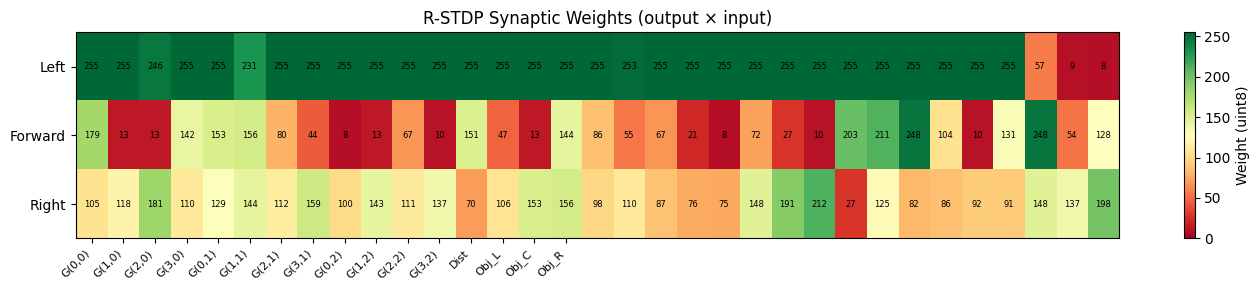

In [22]:
import matplotlib.pyplot as plt

weights = SNN.get_weights()  # shape: (3 output neurons, 16 inputs)
print("Final weights (rows=output neurons, cols=inputs):")
print(weights)

# Input labels for 16 inputs
input_labels = [
    'G(0,0)', 'G(1,0)', 'G(2,0)', 'G(3,0)',  # row 0
    'G(0,1)', 'G(1,1)', 'G(2,1)', 'G(3,1)',  # row 1
    'G(0,2)', 'G(1,2)', 'G(2,2)', 'G(3,2)',  # row 2
    'Dist',                                    # ultrasonic
    'Obj_L', 'Obj_C', 'Obj_R'                # object recognition
]
output_labels = ['Left', 'Forward', 'Right']

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(weights, aspect='auto', cmap='RdYlGn', vmin=0, vmax=255)

ax.set_xticks(range(len(input_labels)))
ax.set_xticklabels(input_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(output_labels)))
ax.set_yticklabels(output_labels)
ax.set_title('R-STDP Synaptic Weights (output × input)')

# Annotate cells
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, f'{weights[i,j]:.0f}', ha='center', va='center', fontsize=6)

plt.colorbar(im, ax=ax, label='Weight (uint8)')
plt.tight_layout()
plt.show()

**Output spike tracking**

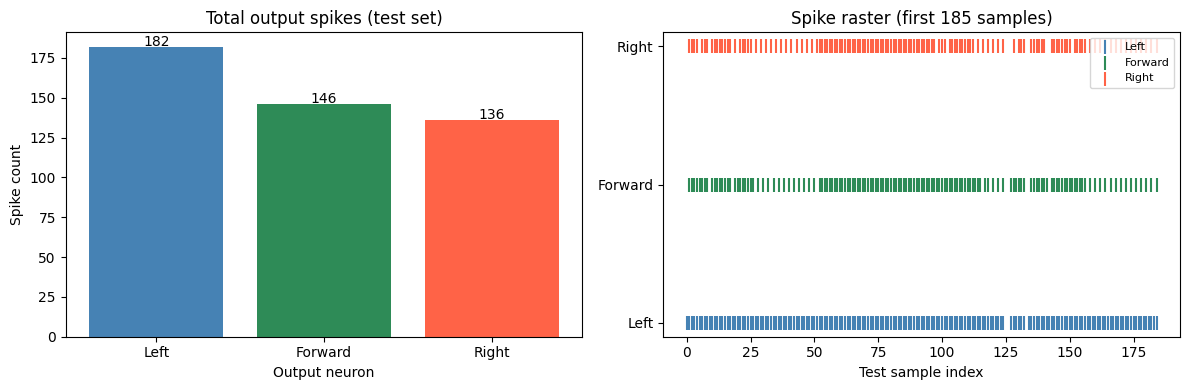

Spike rate per neuron:
      Left: 182/185 = 0.984
   Forward: 146/185 = 0.789
     Right: 136/185 = 0.735


In [23]:
import importlib
import LIF_SNN_network
importlib.reload(LIF_SNN_network)
from LIF_SNN_network import SNNLayer

# Re-run best config for spike tracking on test set
best_neuron_params  = {"decay": 64, "threshold": 512, "reset": 0}
best_synapse_params = {"lr_shift": 3, "w_init": 64,
                       "t_pre": 3, "t_post": 4, "tau_e_shift": 4,
                       "dw_pos": 16, "dw_neg": 32,
                       "w_min": 8, "w_max": 255, "mode": "rstdp"}

np.random.seed(42)
snn_track = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs,
                     synapse_params=best_synapse_params,
                     neuron_params=best_neuron_params,
                     feedback=False)

# Train for 10 epochs (matches tuning loop)
for _ in range(n_epochs):
    snn_track.reset_state()
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):
        output_spikes = snn_track.forward(input_spikes=current_spikes)
        winner_idx    = snn_track.winner_takes_all(output_spikes=output_spikes)
        seen, pos          = parse_aruco_state(current_spikes, aruco_start, n_aruco)
        code, sign, enable = reward_signal(seen, pos, winner_idx, reward_code_range[0], punish_code_range[0])
        if enable:
            snn_track.apply_reward(dopamine_code=code, dopamine_sign=sign, winner_idx=winner_idx)

# --- Test pass: collect per-timestep spikes ---
snn_track.reset_state()
output_labels = ['Left', 'Forward', 'Right']
spike_raster  = []

for current_spikes in test_dataset:
    out = snn_track.forward(input_spikes=current_spikes)
    spike_raster.append(out)

spike_raster = np.array(spike_raster)   # (n_samples, n_outputs)

# --- Plot 1: total spike counts per output neuron ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = snn_track.spike_count
axes[0].bar(output_labels, counts, color=['steelblue', 'seagreen', 'tomato'])
axes[0].set_title('Total output spikes (test set)')
axes[0].set_ylabel('Spike count')
axes[0].set_xlabel('Output neuron')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# --- Plot 2: spike raster (first 200 samples for readability) ---
n_show = min(200, len(spike_raster))
raster_slice = spike_raster[:n_show]

for neuron_idx in range(n_outputs):
    timesteps = np.where(raster_slice[:, neuron_idx] == 1)[0]
    axes[1].scatter(timesteps, np.full_like(timesteps, neuron_idx),
                    marker='|', s=100, linewidths=1.5,
                    color=['steelblue', 'seagreen', 'tomato'][neuron_idx],
                    label=output_labels[neuron_idx])

axes[1].set_yticks(range(n_outputs))
axes[1].set_yticklabels(output_labels)
axes[1].set_xlabel('Test sample index')
axes[1].set_title(f'Spike raster (first {n_show} samples)')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Spike rate per neuron
print("Spike rate per neuron:")
for label, count in zip(output_labels, counts):
    print(f"  {label:>8}: {count}/{len(test_dataset)} = {count/len(test_dataset):.3f}")

In [24]:
# Load grid search results
df = pd.read_csv("CSV_results/SNN_hyperparameter_Results.csv")

# Top 25 configurations
top_25 = df.sort_values(by=['mean_test_acc'], ascending=[False]).head(25)

print("=== Top 25 SNN Configurations ===")
print(top_25[['mean_test_acc', 'decay', 'threshold', 'w_init', 'reset', 'lr_shift', 'mode',
              't_pre', 't_post', 'tau_e_shift', 'dw_pos', 'dw_neg',
              'w_min', 'w_max', 'reward_code', 'punish_code']])

# Parameter impact analysis
print("\n=== Impact of Decay on Accuracy ===")
print(df.groupby('decay')['mean_test_acc'].mean())

print("\n=== Impact of Threshold on Accuracy ===")
print(df.groupby('threshold')['mean_test_acc'].mean())

print("\n=== Impact of lr_shift on Accuracy ===")
print(df.groupby('lr_shift')['mean_test_acc'].mean())

print("\n=== Impact of dw_pos on Accuracy ===")
print(df.groupby('dw_pos')['mean_test_acc'].mean())

print("\n=== Impact of dw_neg on Accuracy ===")
print(df.groupby('dw_neg')['mean_test_acc'].mean())

print("\n=== Impact of tau_e_shift on Accuracy ===")
print(df.groupby('tau_e_shift')['mean_test_acc'].mean())

print("\n=== Impact of w_init on Accuracy ===")
print(df.groupby('w_init')['mean_test_acc'].mean())

print("\n=== Impact of reward_code on Accuracy ===")
print(df.groupby('reward_code')['mean_test_acc'].mean())

print("\n=== Impact of punish_code on Accuracy ===")
print(df.groupby('punish_code')['mean_test_acc'].mean())

# Best overall
print("\n=== Best Overall Config ===")
best = df.sort_values('mean_test_acc', ascending=False).iloc[0]
print(best)

# Worst overall
print("\n=== Worst Overall Config ===")
worst = df.sort_values('mean_test_acc', ascending=True).iloc[0]
print(worst)

=== Top 25 SNN Configurations ===
   mean_test_acc  decay  threshold  w_init  reset  lr_shift   mode  t_pre  \
0       0.275676     64        512     NaN      0         4  rstdp      3   

   t_post  tau_e_shift  dw_pos  dw_neg  w_min  w_max  reward_code  punish_code  
0       2            2      32       2      8    255            0            0  

=== Impact of Decay on Accuracy ===
decay
64    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of Threshold on Accuracy ===
threshold
512    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of lr_shift on Accuracy ===
lr_shift
4    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of dw_pos on Accuracy ===
dw_pos
32    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of dw_neg on Accuracy ===
dw_neg
2    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of tau_e_shift on Accuracy ===
tau_e_shift
2    0.275676
Name: mean_test_acc, dtype: float64

=== Impact of w_init on Accuracy ===
Series([], Name: me